# 05 — Ragionamento Neuro-Simbolico su KANDY Easy

Questo notebook valuta un'architettura ibrida per KANDY Easy in cui un encoder visivo neurale predice **predicati semantici** e un livello simbolico fisso li combina secondo la logica delle task definita da `easy.yml`.

L'esperimento ha due impostazioni complementari:

- **Concetti oracle**: le annotazioni simboliche delle scene vengono convertite in predicati per misurare quanto è espressivo il livello di ragionamento simbolico.
- **Modello neuro-simbolico supervisionato sui predicati**: il predittore neurale dei predicati viene addestrato sulle etichette semantiche estratte offline da `symbol`; il livello simbolico rimane fisso.

L'analisi finale separa gli errori di **grounding visivo** dagli errori del **ragionamento simbolico**.

## Protocollo sperimentale

Il benchmark contiene 20 task binarie. Ogni task contiene campioni generati con attributi di colore e dimensione rumorosi. Le regole simboliche in `easy.yml` definiscono la semantica prevista della classe positiva.

Durante il training, il modello neurale riceve le **etichette dei predicati** costruite offline a partire da `symbol`, ma non riceve l'albero simbolico come input. Le annotazioni simboliche vengono inoltre usate per il benchmark oracle e per verificare se i predicati appresi corrispondono alla semantica prevista.

### Nota metodologica sul ruolo di `symbol`

`symbol` non viene fornito come input alla rete. Viene usato offline per generare le etichette dei predicati e per valutare l'allineamento semantico.

Di conseguenza, questo esperimento è **predicate-supervised**: non è ancora un sistema di concept discovery completamente autonomo. Il prototipo di discovery dinamico viene discusso separatamente come direzione futura.

In [2]:
from pathlib import Path
import ast
import json
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from copy import deepcopy

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cpu":
    torch.set_num_threads(4)

EXPECTED = Path("data") / "samples" / "sets"
ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path.home() / "Downloads" / "kandy-xai",
]

ROOT = next(
    (root.resolve() for root in ROOT_CANDIDATES
     if root.exists() and all((root / EXPECTED / s / "annotations.csv").is_file()
                              for s in ["train", "val", "test"])),
    None,
)

if ROOT is None:
    raise FileNotFoundError("KANDY project root not found. Set ROOT manually.")

DATA_ROOT = ROOT / EXPECTED
SPLIT_DIRS = {s: DATA_ROOT / s for s in ["train", "val", "test"]}
RESULTS_DIR = ROOT / "results" / "neuro_symbolic_final"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("Device:", DEVICE)

ROOT: /home/cosimo/Downloads/kandy-xai
Device: cpu


In [4]:
def load_split(split):
    frame = pd.read_csv(SPLIT_DIRS[split] / "annotations.csv").copy()
    frame["task_id"] = pd.to_numeric(frame["task_id"], errors="raise").astype(int)
    frame["label"] = pd.to_numeric(frame["label"], errors="raise").astype(int)
    frame["symbol_parsed"] = frame["symbol"].apply(ast.literal_eval)
    frame["split"] = split
    return frame

splits = {s: load_split(s) for s in ["train", "val", "test"]}

TASK_NAMES = {
    0: "triangle vs any",
    1: "square vs any",
    2: "circle vs any",
    3: "red vs any",
    4: "green vs any",
    5: "blue vs any",
    6: "cyan vs any",
    7: "magenta vs any",
    8: "yellow vs any",
    9: "red triangle on the right",
    10: "red triangle on the right and arbitrary objects",
    11: "red triangle on the right and at least one circle and arbitrary objects",
    12: "red triangle on the right and at least one blue object and arbitrary objects",
    13: "triangle and square, same color",
    14: "palindrome aba",
    15: "house",
    16: "car",
    17: "tower",
    18: "wagon",
    19: "traffic light",
}

for split, frame in splits.items():
    print(f"{split:>5}: {len(frame)} samples")

train: 1000 samples
  val: 500 samples
 test: 500 samples


## 1. Spazio compatto dei concetti simbolici

L'interfaccia contiene solo i predicati semantici necessari per descrivere le 20 regole di KANDY Easy. I concetti espliciti basati su slot di oggetti non vengono usati perché introdurrebbero una struttura più difficile da apprendere a partire dalla sola immagine.

In [5]:
SHAPES = ["triangle", "square", "circle"]
COLORS = ["red", "green", "blue", "cyan", "magenta", "yellow"]

PREDICATE_NAMES = [
    "has_triangle", "has_square", "has_circle",
    "has_red", "has_green", "has_blue", "has_cyan", "has_magenta", "has_yellow",
    "last_is_red_triangle", "exists_circle_before_last", "exists_blue_before_last",
    "triangle_square_same_color", "palindrome_sequence",
    "house_structure", "car_structure", "tower_structure", "wagon_structure",
    "traffic_light_structure",
]

print("Dimensione del vocabolario dei predicati:", len(PREDICATE_NAMES))

Dimensione del vocabolario dei predicati: 19


## 2. Codifica simbolica

Il parser della scena mantiene la sequenza ordinata degli oggetti e le relazioni locali (`stack` o `side_by_side`) utilizzate dalle regole strutturali di KANDY.

Il risultato viene trasformato in un vettore di predicati binari. Queste etichette costituiscono il **target semantico** della fase di grounding neurale.

In [6]:
def atomic_object(node):
    return isinstance(node, dict) and {"shape", "color", "size"}.issubset(node.keys())

def child_relation(node):
    if not isinstance(node, dict):
        return None, None
    for key in ("side_by_side", "stack"):
        value = node.get(key)
        if isinstance(value, list):
            return key, value
    return None, None

def iter_atoms(node):
    if atomic_object(node):
        yield {key: node[key] for key in ("shape", "color", "size")}
        return
    if isinstance(node, dict):
        for value in node.values():
            if isinstance(value, (dict, list)):
                yield from iter_atoms(value)
    elif isinstance(node, list):
        for value in node:
            yield from iter_atoms(value)

def iter_composites(node):
    relation, children = child_relation(node)
    if children is not None:
        yield relation, children
        for child in children:
            yield from iter_composites(child)
        return

    if isinstance(node, dict):
        for value in node.values():
            if isinstance(value, (dict, list)):
                yield from iter_composites(value)
    elif isinstance(node, list):
        for value in node:
            yield from iter_composites(value)

def same_size(objects):
    return len(objects) >= 2 and len({obj["size"] for obj in objects}) == 1

def local_structure_predicates(symbol):
    result = {
        "house_structure": False,
        "car_structure": False,
        "tower_structure": False,
        "wagon_structure": False,
        "traffic_light_structure": False,
    }

    for relation, children in iter_composites(symbol):
        if not children or not all(atomic_object(child) for child in children):
            continue

        if (
            relation == "stack"
            and len(children) == 2
            and {child["shape"] for child in children} == {"triangle", "square"}
            and same_size(children)
        ):
            result["house_structure"] = True

        if (
            relation == "side_by_side"
            and len(children) == 2
            and all(child["shape"] == "circle" for child in children)
            and same_size(children)
        ):
            result["car_structure"] = True

        if (
            relation == "stack"
            and len(children) in {2, 3}
            and all(child["shape"] == "square" for child in children)
            and same_size(children)
        ):
            result["tower_structure"] = True

        if (
            relation == "side_by_side"
            and len(children) in {2, 3}
            and all(child["shape"] == "square" for child in children)
            and same_size(children)
        ):
            result["wagon_structure"] = True

        if (
            relation == "stack"
            and len(children) == 3
            and [child["shape"] for child in children] == ["circle", "circle", "circle"]
            and [child["color"] for child in children] == ["red", "yellow", "green"]
            and same_size(children)
        ):
            result["traffic_light_structure"] = True

    return result

def scene_predicates(symbol):
    objects = list(iter_atoms(symbol))
    values = {name: 0.0 for name in PREDICATE_NAMES}

    for shape in SHAPES:
        values[f"has_{shape}"] = float(any(obj["shape"] == shape for obj in objects))

    for color in COLORS:
        values[f"has_{color}"] = float(any(obj["color"] == color for obj in objects))

    if objects:
        last = objects[-1]
        values["last_is_red_triangle"] = float(
            last["shape"] == "triangle" and last["color"] == "red"
        )
        values["exists_circle_before_last"] = float(
            any(obj["shape"] == "circle" for obj in objects[:-1])
        )
        values["exists_blue_before_last"] = float(
            any(obj["color"] == "blue" for obj in objects[:-1])
        )

    triangles = [obj for obj in objects if obj["shape"] == "triangle"]
    squares = [obj for obj in objects if obj["shape"] == "square"]
    values["triangle_square_same_color"] = float(
        any(t["color"] == s["color"] for t in triangles for s in squares)
    )

    sequence = [(obj["shape"], obj["color"], obj["size"]) for obj in objects]
    values["palindrome_sequence"] = float(sequence == list(reversed(sequence)))

    values.update({
        key: float(value)
        for key, value in local_structure_predicates(symbol).items()
    })
    return values

for frame in splits.values():
    predicate_frame = pd.DataFrame(
        frame["symbol_parsed"].apply(scene_predicates).tolist(),
        index=frame.index,
    )
    for name in PREDICATE_NAMES:
        frame[name] = predicate_frame[name].astype(np.float32)

print(
    pd.concat([splits[name][PREDICATE_NAMES] for name in ["train", "val", "test"]])
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

palindrome_sequence          0.5140
has_triangle                 0.4890
has_square                   0.4885
has_circle                   0.4675
has_red                      0.3485
has_blue                     0.2785
has_green                    0.2785
exists_circle_before_last    0.2710
has_cyan                     0.2675
has_magenta                  0.2610
dtype: float32


## 3. Livello di regole differenziabile fisso

Le regole rimangono fisse e non vengono apprese.

La congiunzione fuzzy tramite prodotto fornisce un'interfaccia differenziabile tra le probabilità predette dalla rete e i punteggi delle task.

In [7]:
def fuzzy_and(*values):
    result = values[0]
    for value in values[1:]:
        result = result * value
    return result

class SymbolicRuleLayer(nn.Module):
    def __init__(self, predicate_names):
        super().__init__()
        self.index = {name: i for i, name in enumerate(predicate_names)}

    def p(self, x, name):
        return x[:, self.index[name]]

    def forward(self, x):
        p = self.p
        scores = [
            p(x, "has_triangle"),
            p(x, "has_square"),
            p(x, "has_circle"),
            p(x, "has_red"),
            p(x, "has_green"),
            p(x, "has_blue"),
            p(x, "has_cyan"),
            p(x, "has_magenta"),
            p(x, "has_yellow"),
            p(x, "last_is_red_triangle"),
            p(x, "last_is_red_triangle"),
            fuzzy_and(
                p(x, "last_is_red_triangle"),
                p(x, "exists_circle_before_last"),
            ),
            fuzzy_and(
                p(x, "last_is_red_triangle"),
                p(x, "exists_blue_before_last"),
            ),
            p(x, "triangle_square_same_color"),
            p(x, "palindrome_sequence"),
            p(x, "house_structure"),
            p(x, "car_structure"),
            p(x, "tower_structure"),
            p(x, "wagon_structure"),
            p(x, "traffic_light_structure"),
        ]
        return torch.stack(scores, dim=1)

## 4. Benchmark simbolico oracle

I predicati simbolici ground truth vengono passati direttamente al livello di regole fisso.

Questo esperimento stabilisce un riferimento per la componente di ragionamento e verifica quanto bene il vocabolario scelto di predicati catturi la semantica di KANDY Easy.

In [8]:
rule_layer = SymbolicRuleLayer(PREDICATE_NAMES).to(DEVICE)

oracle_metrics = []

for task_id in range(20):
    frame = splits["test"][splits["test"].task_id == task_id]
    X = torch.tensor(frame[PREDICATE_NAMES].to_numpy(dtype=np.float32), device=DEVICE)
    y = frame["label"].to_numpy(dtype=int)

    with torch.no_grad():
        scores = rule_layer(X)[:, task_id]
        prediction = (scores >= 0.5).long().cpu().numpy()

    oracle_metrics.append({
        "task_id": task_id,
        "task_name": TASK_NAMES[task_id],
        "accuracy": accuracy_score(y, prediction),
        "f1": f1_score(y, prediction, zero_division=0),
    })

oracle_results = pd.DataFrame(oracle_metrics)
display(oracle_results)
print("Accuracy media oracle:", round(oracle_results["accuracy"].mean(), 3))
print("F1 medio oracle:", round(oracle_results["f1"].mean(), 3))
oracle_results.to_csv(RESULTS_DIR / "oracle_results.csv", index=False)


,task_id,task_name,accuracy,f1
0,0,triangle vs any,1.0,1.0
1,1,square vs any,1.0,1.0
2,2,circle vs any,1.0,1.0
3,3,red vs any,1.0,1.0
4,4,green vs any,1.0,1.0
5,5,blue vs any,1.0,1.0
6,6,cyan vs any,1.0,1.0
7,7,magenta vs any,1.0,1.0
8,8,yellow vs any,1.0,1.0
9,9,red triangle on the right,1.0,1.0


Accuracy media oracle: 1.0
F1 medio oracle: 1.0


## 5. Grounding neuro-simbolico supervisionato sui predicati

Il modello visivo viene addestrato a predire i predicati semantici estratti da `symbol`.

Le label delle task forniscono inoltre un obiettivo di coerenza end-to-end: il punteggio della task deve rimanere compatibile con la label osservata.

La predizione finale passa comunque attraverso il livello simbolico fisso.

In [9]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 18
LR_HEAD = 1e-3
TASK_LOSS_WEIGHT = 0.25

TRANSFORM = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225],
    ),
])

class KANDYConceptDataset(Dataset):
    def __init__(self, frame, image_dir):
        self.frame = frame.reset_index(drop=True)
        self.image_dir = Path(image_dir)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image = Image.open(self.image_dir / row["filename"]).convert("RGB")
        concepts = torch.tensor(
            row[PREDICATE_NAMES].to_numpy(dtype=np.float32)
        )
        return TRANSFORM(image), int(row["task_id"]), int(row["label"]), concepts

class NeuralPredicateModel(nn.Module):
    def __init__(self, n_predicates):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])
        self.predicate_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(256, n_predicates),
        )
        self.rule_layer = SymbolicRuleLayer(PREDICATE_NAMES)

    def forward(self, images):
        features = self.encoder(images)
        logits = self.predicate_head(features)
        probabilities = torch.sigmoid(logits)
        task_scores = self.rule_layer(probabilities)
        return logits, probabilities, task_scores

train_loader = DataLoader(
    KANDYConceptDataset(splits["train"], SPLIT_DIRS["train"]),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    KANDYConceptDataset(splits["val"], SPLIT_DIRS["val"]),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    KANDYConceptDataset(splits["test"], SPLIT_DIRS["test"]),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

model = NeuralPredicateModel(len(PREDICATE_NAMES)).to(DEVICE)

for parameter in model.encoder.parameters():
    parameter.requires_grad = False

train_concepts = splits["train"][PREDICATE_NAMES].to_numpy(dtype=np.float32)
positive = train_concepts.sum(axis=0)
negative = len(train_concepts) - positive

concept_weight = torch.tensor(
    negative / np.maximum(positive, 1.0),
    dtype=torch.float32,
    device=DEVICE,
).clamp(max=20.0)

criterion_concept = nn.BCEWithLogitsLoss(pos_weight=concept_weight)
optimizer = torch.optim.AdamW(
    model.predicate_head.parameters(),
    lr=LR_HEAD,
    weight_decay=1e-4,
)

def selected_task_score(scores, task_ids):
    return scores[
        torch.arange(len(task_ids), device=DEVICE),
        task_ids,
    ]

history = []
best_state = None
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for images, task_ids, labels, concepts in train_loader:
        images = images.to(DEVICE)
        task_ids = task_ids.to(DEVICE)
        labels = labels.to(DEVICE).float()
        concepts = concepts.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        logits, _, scores = model(images)
        concept_loss = criterion_concept(logits, concepts)
        task_score = selected_task_score(scores, task_ids).clamp(1e-5, 1 - 1e-5)
        task_loss = nn.functional.binary_cross_entropy(task_score, labels)
        loss = concept_loss + TASK_LOSS_WEIGHT * task_loss

        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []

    with torch.no_grad():
        for images, task_ids, labels, concepts in val_loader:
            images = images.to(DEVICE)
            task_ids = task_ids.to(DEVICE)
            labels = labels.to(DEVICE).float()
            concepts = concepts.to(DEVICE)

            logits, _, scores = model(images)
            concept_loss = criterion_concept(logits, concepts)
            task_score = selected_task_score(scores, task_ids).clamp(1e-5, 1 - 1e-5)
            task_loss = nn.functional.binary_cross_entropy(task_score, labels)
            val_losses.append(
                (concept_loss + TASK_LOSS_WEIGHT * task_loss).item()
            )

    val_loss = float(np.mean(val_losses))
    history.append({
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        "val_loss": val_loss,
    })

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = deepcopy(model.state_dict())

if best_state is not None:
    model.load_state_dict(best_state)

display(pd.DataFrame(history).tail())

,epoch,train_loss,val_loss
13,14,0.437632,0.589427
14,15,0.445726,0.560849
15,16,0.411664,0.567826
16,17,0.424407,0.568976
17,18,0.399809,0.592275


In [10]:
model.eval()

task_ids_all = []
labels_all = []
scores_all = []
predicates_all = []

with torch.no_grad():
    for images, task_ids, labels, _ in test_loader:
        _, probabilities, task_scores = model(images.to(DEVICE))
        task_ids_all.append(task_ids.numpy())
        labels_all.append(labels.numpy())
        scores_all.append(task_scores.cpu().numpy())
        predicates_all.append(probabilities.cpu().numpy())

test_task_ids = np.concatenate(task_ids_all)
test_labels = np.concatenate(labels_all)
test_scores = np.concatenate(scores_all)
test_predicates = np.concatenate(predicates_all)

ns_rows = []

for task_id in range(20):
    mask = test_task_ids == task_id
    y_true = test_labels[mask]
    y_pred = (test_scores[mask, task_id] >= 0.5).astype(int)

    ns_rows.append({
        "task_id": task_id,
        "task_name": TASK_NAMES[task_id],
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    })

neurosymbolic_results = pd.DataFrame(ns_rows)
display(neurosymbolic_results)
print(
    "Accuracy media neuro-simbolica:",
    round(neurosymbolic_results["accuracy"].mean(), 3),
)
print(
    "F1 medio neuro-simbolica:",
    round(neurosymbolic_results["f1"].mean(), 3),
)

,task_id,task_name,accuracy,f1
0,0,triangle vs any,1.00,1.000000
1,1,square vs any,0.92,0.900000
2,2,circle vs any,0.92,0.923077
3,3,red vs any,0.96,0.941176
4,4,green vs any,0.96,0.933333
5,5,blue vs any,0.96,0.956522
6,6,cyan vs any,0.96,0.933333
7,7,magenta vs any,1.00,1.000000
8,8,yellow vs any,1.00,1.000000
9,9,red triangle on the right,0.96,0.941176


Accuracy media neuro-simbolica: 0.828
F1 medio neuro-simbolica: 0.772


## 6. Allineamento dei predicati

L'F1 a livello di predicato verifica se l'encoder neurale sta effettuando il grounding dei concetti semantici previsti invece di imparare soltanto una scorciatoia specifica per la task.

In [11]:
predicate_true = splits["test"][PREDICATE_NAMES].to_numpy(dtype=np.float32)
predicate_pred = (test_predicates >= 0.5).astype(np.float32)

predicate_rows = []

for index, name in enumerate(PREDICATE_NAMES):
    predicate_rows.append({
        "predicate": name,
        "f1": f1_score(
            predicate_true[:, index],
            predicate_pred[:, index],
            zero_division=0,
        ),
        "positive_rate": predicate_true[:, index].mean(),
    })

predicate_results = (
    pd.DataFrame(predicate_rows)
    .sort_values("f1", ascending=False)
)

display(predicate_results)

,predicate,f1,positive_rate
3,has_red,0.964497,0.342
2,has_circle,0.882845,0.496
5,has_blue,0.881579,0.290
7,has_magenta,0.857143,0.284
4,has_green,0.850498,0.292
13,palindrome_sequence,0.846580,0.510
9,last_is_red_triangle,0.819672,0.154
6,has_cyan,0.817460,0.270
1,has_square,0.807619,0.466
10,exists_circle_before_last,0.775510,0.282


## 7. Intervento sui concetti e robustezza

In [12]:
#ablazione di un singolo concetto: quanto influisce ogni predicato sulle regole fisse?
intervention_rows = []

for idx, name in enumerate(PREDICATE_NAMES):
    x = torch.tensor(test_predicates, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        base = rule_layer(x).cpu().numpy()
        x[:, idx] = 0.0
        ablated = rule_layer(x).cpu().numpy()

    delta = base - ablated
    for task_id in range(20):
        mask = test_task_ids == task_id
        if not np.any(mask):
            continue
        intervention_rows.append({
            'predicate': name,
            'task_id': task_id,
            'mean_score_drop': float(delta[mask, task_id].mean()),
            'positive_score_drop': float(delta[mask & (test_labels == 1), task_id].mean()) if np.any(mask & (test_labels == 1)) else np.nan,
        })

intervention_results = pd.DataFrame(intervention_rows)
display(
    intervention_results
    .sort_values(['mean_score_drop', 'predicate'], ascending=[False, True])
    .head(30)
)
intervention_results.to_csv(RESULTS_DIR / 'concept_interventions.csv', index=False)

,predicate,task_id,mean_score_drop,positive_score_drop
211,exists_circle_before_last,11,0.704149,0.779064
191,last_is_red_triangle,11,0.704149,0.779064
190,last_is_red_triangle,10,0.698470,0.808963
232,exists_blue_before_last,12,0.662855,0.791594
192,last_is_red_triangle,12,0.662855,0.791594
21,has_square,1,0.509220,0.841977
295,house_structure,15,0.505079,0.591471
337,tower_structure,17,0.490487,0.873570
358,wagon_structure,18,0.483461,0.579726
42,has_circle,2,0.465694,0.725225


### Robustezza al rumore del bottleneck

Un secondo test misura come cambia la classificazione quando una frazione dei concetti binari viene invertita.

L'esperimento usa le predizioni del modello e non le etichette gold dei concetti.

In [13]:
def evaluate_with_binary_noise(noise_rate, seed=42):
    rng = np.random.default_rng(seed)
    noisy = (test_predicates >= 0.5).astype(np.float32)

    flips = rng.random(noisy.shape) < noise_rate
    noisy[flips] = 1.0 - noisy[flips]

    x = torch.tensor(noisy, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        scores = rule_layer(x).cpu().numpy()

    y_pred = np.zeros_like(test_labels)
    for task_id in range(20):
        mask = test_task_ids == task_id
        y_pred[mask] = (scores[mask, task_id] >= 0.5).astype(int)

    return accuracy_score(test_labels, y_pred)

robustness = pd.DataFrame({
    'noise_rate': [0.00, 0.05, 0.10, 0.20, 0.30],
    'task_accuracy': [evaluate_with_binary_noise(r) for r in [0.00, 0.05, 0.10, 0.20, 0.30]],
})
display(robustness)
robustness.to_csv(RESULTS_DIR / 'concept_noise_robustness.csv', index=False)

,noise_rate,task_accuracy
0,0.00,0.828
1,0.05,0.814
2,0.10,0.782
3,0.20,0.730
4,0.30,0.660


## 8. Decomposizione degli errori

Il benchmark oracle misura il limite superiore del livello di ragionamento simbolico fissato.

La differenza residua rispetto all'oracle può quindi essere interpretata principalmente come errore di **grounding visivo dei predicati**.

In [14]:
oracle_map = oracle_results.set_index("task_id")
ns_map = neurosymbolic_results.set_index("task_id")

decomposition = pd.DataFrame({
    "task_id": range(20),
    "task_name": [TASK_NAMES[i] for i in range(20)],
    "oracle_accuracy": [oracle_map.loc[i, "accuracy"] for i in range(20)],
    "neuro_symbolic_accuracy": [ns_map.loc[i, "accuracy"] for i in range(20)],
})

decomposition["accuracy_drop_from_perception"] = (
    decomposition["oracle_accuracy"]
    - decomposition["neuro_symbolic_accuracy"]
)

display(
    decomposition.sort_values(
        "accuracy_drop_from_perception",
        ascending=False,
    )
)

,task_id,task_name,oracle_accuracy,neuro_symbolic_accuracy,accuracy_drop_from_perception
14,14,palindrome aba,1.0,0.44,0.56
16,16,car,1.0,0.52,0.48
13,13,"triangle and square, same color",1.0,0.56,0.44
15,15,house,1.0,0.64,0.36
18,18,wagon,1.0,0.64,0.36
11,11,red triangle on the right and at least one cir...,1.0,0.72,0.28
12,12,red triangle on the right and at least one blu...,1.0,0.80,0.20
17,17,tower,1.0,0.84,0.16
10,10,red triangle on the right and arbitrary objects,1.0,0.88,0.12
19,19,traffic light,1.0,0.88,0.12


## 9. Confronto finale

Il risultato della precedente versione weakly supervised v2 viene mantenuto come riferimento storico.

Il modello attuale studia invece se un grounding esplicito sui predicati semantici migliora la stessa pipeline di ragionamento simbolico fisso.

## Interpretazione

I valori oracle e weakly supervised costituiscono due riferimenti utili:

- **Oracle simbolico**: accuracy media 1.000, F1 medio 1.000.
- **Weakly supervised v2**: accuracy media 0.768, F1 medio 0.699.

Il nuovo risultato va interpretato considerando sia la prestazione sulle task sia l'allineamento dei predicati.

Un aumento della prestazione sulle task accompagnato da un migliore F1 sui predicati indica un miglioramento del **grounding visivo semantico**, invece di una semplice memorizzazione specifica della task.

## 10. Visualizzazione dei concept su una singola istanza

Le tabelle aggregate misurano quanto bene il modello predice le task e i singoli predicati, ma non mostrano **come il modello arriva alla decisione su una singola immagine**.

La visualizzazione seguente prende una singola istanza e mostra:

- l'immagine;
- task e label reale;
- i predicati attivi sopra una soglia;
- la probabilità associata a ogni predicato;
- il punteggio della regola relativo alla task dell'istanza.

In questo modo il bottleneck diventa osservabile come una serie di **spie concettuali**.

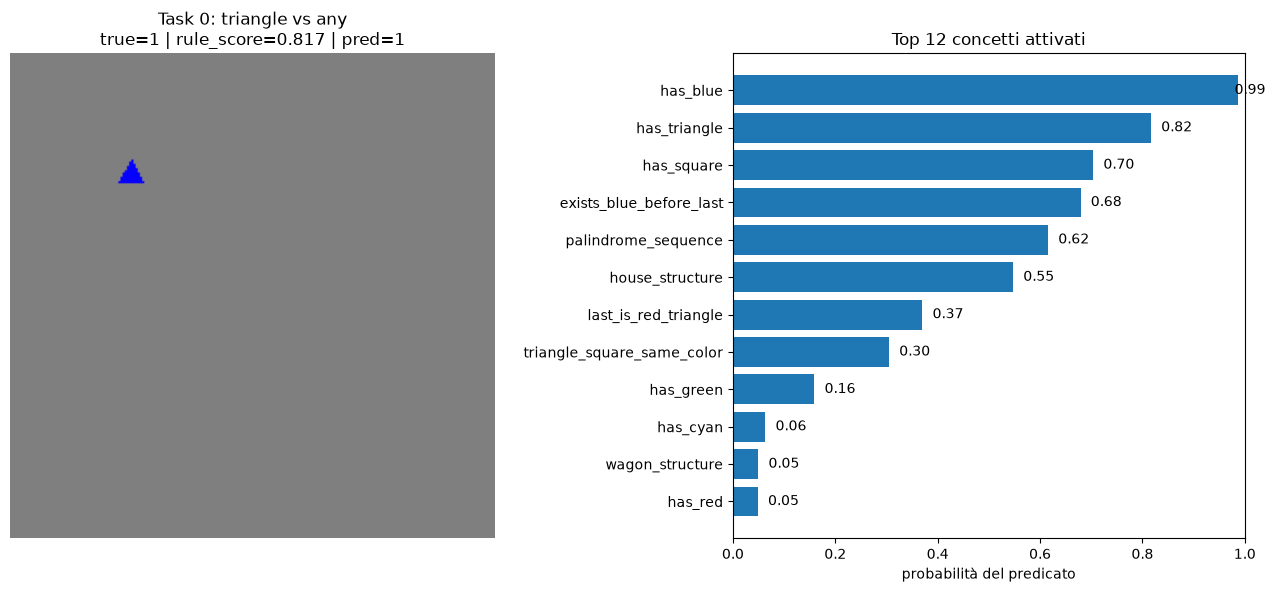

Figura salvata in:
/home/cosimo/Downloads/kandy-xai/results/neuro_symbolic_final/concept_visualizations/test_index_0_task_0_concepts.png

Tabella salvata in:
/home/cosimo/Downloads/kandy-xai/results/neuro_symbolic_final/concept_visualizations/test_index_0_task_0_concepts.csv


,predicate,probability,active
0,has_blue,0.987231,True
1,has_triangle,0.816706,True
2,has_square,0.703766,True
3,exists_blue_before_last,0.679120,True
4,palindrome_sequence,0.615640,True
5,house_structure,0.547255,True
6,last_is_red_triangle,0.370014,False
7,triangle_square_same_color,0.304836,False
8,has_green,0.159039,False
9,has_cyan,0.063221,False


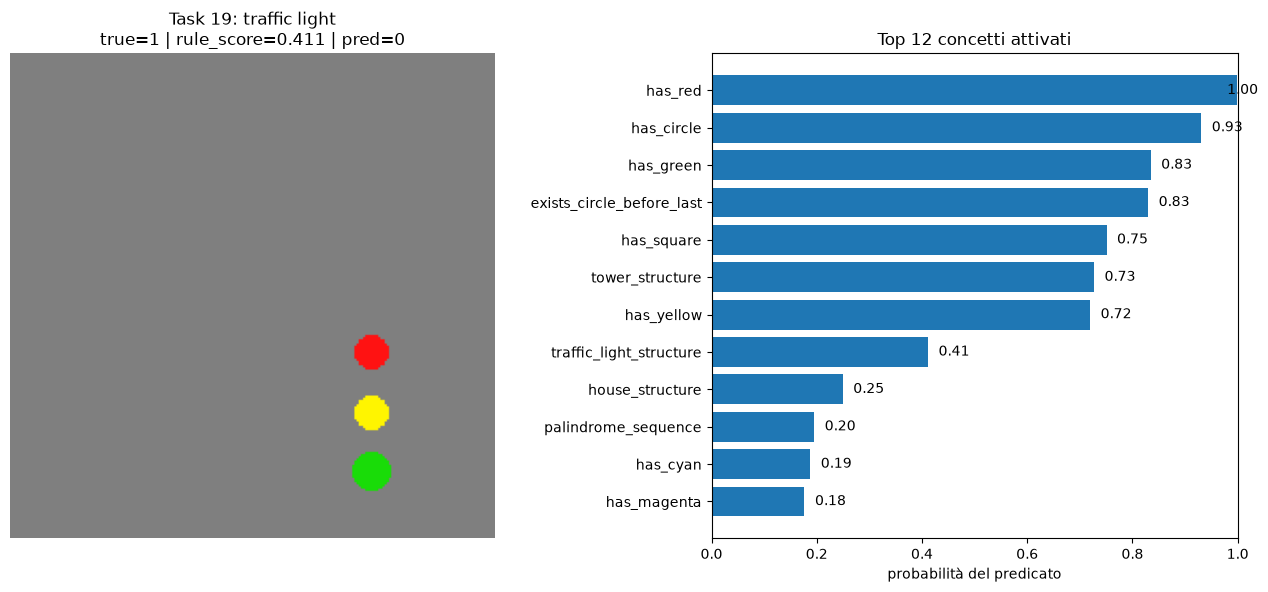

Figura salvata in:
/home/cosimo/Downloads/kandy-xai/results/neuro_symbolic_final/concept_visualizations/test_index_490_task_19_concepts.png

Tabella salvata in:
/home/cosimo/Downloads/kandy-xai/results/neuro_symbolic_final/concept_visualizations/test_index_490_task_19_concepts.csv


,predicate,probability,active
0,has_red,0.998594,True
1,has_circle,0.930818,True
2,has_green,0.834651,True
3,exists_circle_before_last,0.829852,True
4,has_square,0.750707,True
5,tower_structure,0.726994,True
6,has_yellow,0.719534,True
7,traffic_light_structure,0.411482,False
8,house_structure,0.249418,False
9,palindrome_sequence,0.195166,False


In [17]:
@torch.no_grad()
def show_instance_concepts(index=0, split="test", threshold=0.5, top_k=12):
    frame = splits[split].reset_index(drop=True)
    row = frame.iloc[index]

    image_path = SPLIT_DIRS[split] / row["filename"]
    image = Image.open(image_path).convert("RGB")
    x = TRANSFORM(image).unsqueeze(0).to(DEVICE)

    logits, probabilities, task_scores = model(x)

    concept_probs = probabilities[0].detach().cpu().numpy()
    task_scores_np = task_scores[0].detach().cpu().numpy()

    task_id = int(row["task_id"])
    true_label = int(row["label"])
    predicted_label = int(task_scores_np[task_id] >= 0.5)

    order = np.argsort(-concept_probs)
    selected = order[:top_k]

    selected_names = [PREDICATE_NAMES[i] for i in selected]
    selected_values = [float(concept_probs[i]) for i in selected]
    selected_active = [
        bool(concept_probs[i] >= threshold)
        for i in selected
    ]

    concept_results = pd.DataFrame({
        "predicate": selected_names,
        "probability": selected_values,
        "active": selected_active,
    }).sort_values(
        "probability",
        ascending=False,
    )

    concept_dir = RESULTS_DIR / "concept_visualizations"
    concept_dir.mkdir(parents=True, exist_ok=True)

    csv_path = concept_dir / (
        f"{split}_index_{index}_task_{task_id}_concepts.csv"
    )

    concept_results.to_csv(
        csv_path,
        index=False,
    )

    all_concept_results = pd.DataFrame({
    "predicate": PREDICATE_NAMES,
    "probability": concept_probs,
    "active": concept_probs >= threshold,
    })
    
    all_csv_path = concept_dir / (
        f"{split}_index_{index}_task_{task_id}_all_concepts.csv"
    )
    
    all_concept_results.to_csv(
        all_csv_path,
        index=False,
    )

    names = selected_names[::-1]
    values = selected_values[::-1]

    fig = plt.figure(figsize=(13, 6))

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(image)
    ax1.axis("off")

    ax1.set_title(
        f"Task {task_id}: {TASK_NAMES[task_id]}\n"
        f"true={true_label} | "
        f"rule_score={task_scores_np[task_id]:.3f} | "
        f"pred={predicted_label}"
    )

    ax2 = fig.add_subplot(1, 2, 2)

    ax2.barh(
        names,
        values,
    )

    ax2.set_xlim(0, 1)
    ax2.set_xlabel("probabilità del predicato")
    ax2.set_title("Top 12 concetti attivati")

    for y, value in enumerate(values):
        ax2.text(
            min(value + 0.02, 0.98),
            y,
            f"{value:.2f}",
            va="center",
        )

    plt.tight_layout()

    png_path = concept_dir / (
        f"{split}_index_{index}_task_{task_id}_concepts.png"
    )

    plt.savefig(
        png_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print("Figura salvata in:")
    print(png_path)

    print("\nTabella salvata in:")
    print(csv_path)

    display(concept_results)


show_instance_concepts(index=0, split="test")
show_instance_concepts(index=490, split="test")

### Come leggere la visualizzazione

Per esempio, una singola istanza potrebbe produrre:

```text
has_triangle                0.97   ON
has_red                     0.94   ON
last_is_red_triangle        0.91   ON
exists_circle_before_last  0.88   ON
has_blue                    0.07   OFF
palindrome_sequence         0.03   OFF
```

e la regola della task potrebbe avere `rule_score = 0.80`.

La lettura diventa quindi:

> il modello assegna alta probabilità alla presenza di un triangolo, di un oggetto rosso, di un triangolo rosso come ultimo elemento e di un cerchio prima dell'ultimo elemento; la combinazione di questi predicati produce il punteggio della regola.

Questo è più informativo della sola accuracy media perché permette di osservare il **percorso intermedio** tra immagine e decisione.